In [52]:
# ! pip install -q datasets
# ! pip install -q transformers
# ! pip install -q sentencepiece
# ! pip install protobuf tiktoken



In [53]:
import pandas as pd

In [54]:
# read the dataset
df = pd.read_csv("./train.csv")

In [55]:
df

,id,anchor,target,context,score
0,37d61fd2272659b1,abatement,abatement of pollution,A47,0.50
1,7b9652b17b68b7a4,abatement,act of abating,A47,0.75
2,36d72442aefd8232,abatement,active catalyst,A47,0.25
3,5296b0c19e1ce60e,abatement,eliminating process,A47,0.50
4,54c1e3b9184cb5b6,abatement,forest region,A47,0.00
...,...,...,...,...,...
36468,8e1386cbefd7f245,wood article,wooden article,B44,1.00
36469,42d9e032d1cd3242,wood article,wooden box,B44,0.50
36470,208654ccb9e14fa3,wood article,wooden handle,B44,0.50
36471,756ec035e694722b,wood article,wooden material,B44,0.75


In [56]:
# Let's try to understand the dataset from high level
df.describe(include="str")

,id,anchor,target,context
count,36473,36473,36473,36473
unique,36473,733,29340,106
top,37d61fd2272659b1,component composite coating,composition,H01
freq,1,152,24,2186


In [57]:
# Let's create a new field called 'input'
df["input"] = 'TEXT1: ' + df.context + '; TEXT2: '+ df.target + '; ANC1: '+ df.anchor

In [58]:
df.input.head(10)

0    TEXT1: A47; TEXT2: abatement of pollution; ANC...
1    TEXT1: A47; TEXT2: act of abating; ANC1: abate...
2    TEXT1: A47; TEXT2: active catalyst; ANC1: abat...
3    TEXT1: A47; TEXT2: eliminating process; ANC1: ...
4    TEXT1: A47; TEXT2: forest region; ANC1: abatement
5    TEXT1: A47; TEXT2: greenhouse gases; ANC1: aba...
6    TEXT1: A47; TEXT2: increased rate; ANC1: abate...
7    TEXT1: A47; TEXT2: measurement level; ANC1: ab...
8    TEXT1: A47; TEXT2: minimising sounds; ANC1: ab...
9    TEXT1: A47; TEXT2: mixing core materials; ANC1...
Name: input, dtype: str

Convert pandas dataframe into huggingface dataset

In [59]:
from datasets import Dataset, DatasetDict

ds = Dataset.from_pandas(df)

In [60]:
ds

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'score', 'input'],
    num_rows: 36473
})

- Tokenization: convert each text up into words (sometimes subwords)
- Numericalization: Convert each word (or token) into a number

In [61]:
model_nm =  'microsoft/deberta-v3-small'

`Autotokenizer` will create a tokenizer appropriate for a given model

In [62]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
tokz = AutoTokenizer.from_pretrained(model_nm)

In [63]:
tokz.tokenize('Hello! this is a hilarious news for the psychologist!')

['▁Hello',
 '!',
 '▁this',
 '▁is',
 '▁a',
 '▁hilarious',
 '▁news',
 '▁for',
 '▁the',
 '▁psychologist',
 '!']

Uknown words will split into pieces. The start of a new word is represented by `_`

In [64]:
tokz.tokenize('The maghbanierly is whiteflur than jerrky')

['▁The',
 '▁mag',
 'h',
 'bani',
 'erly',
 '▁is',
 '▁white',
 'flu',
 'r',
 '▁than',
 '▁jer',
 'r',
 'ky']

In [65]:
#total vocabolary length
len(tokz.vocab)

128001

function for tokenize our input

In [66]:
def tok_func(x): return tokz(x['input'])

In [67]:
tok_ds = ds.map(tok_func, batched=True)

Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

In [68]:
#a sample row
row = tok_ds[0]
row

{'id': '37d61fd2272659b1',
 'anchor': 'abatement',
 'target': 'abatement of pollution',
 'context': 'A47',
 'score': 0.5,
 'input': 'TEXT1: A47; TEXT2: abatement of pollution; ANC1: abatement',
 'input_ids': [1,
  54453,
  435,
  294,
  336,
  5753,
  346,
  54453,
  445,
  294,
  47284,
  265,
  6435,
  346,
  23702,
  435,
  294,
  47284,
  2],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

This adds a new item in our dataset called input_ids. For instance, here is the input and IDs for the first row of our data

In [69]:
row['input'], row['input_ids']

('TEXT1: A47; TEXT2: abatement of pollution; ANC1: abatement',
 [1,
  54453,
  435,
  294,
  336,
  5753,
  346,
  54453,
  445,
  294,
  47284,
  265,
  6435,
  346,
  23702,
  435,
  294,
  47284,
  2])

So, what are those IDs and where do they come from? The secret is that there's a list called vocab in the tokenizer which contains a unique integer for every possible token string. We can look them up like this, for instance to find the token for the word `of`:

In [70]:
{v: k for k, v in tokz.vocab.items()}[265]

'▁of'

In [71]:
tokz.vocab['▁of']

265

transformers expect labels name to be `labels`, but in our dataset, it is `score`. Let's change this

In [72]:
tok_ds = tok_ds.rename_columns({'score': 'labels'})
tok_ds = tok_ds.map(lambda x: {'labels': float(x['labels'])})

Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

### Test and Validation Set

In [73]:
eval_df = pd.read_csv('./test.csv')

In [74]:
eval_df.describe()

,id,anchor,target,context
count,36,36,36,36
unique,36,34,36,29
top,4112d61851461f60,el display,inorganic photoconductor drum,G02
freq,1,2,1,3


This is the test set. Possibly the most important idea in machine learning is that of having separate training, validation, and test data sets.

### Validation Set

To explain the motivation, let's start simple, and imagine we're trying to fit a model where the true relationship is this quadratic:

In [75]:
def f(x):
    return -3 * x**2 + 2 * x + 20

Let's visualize this function in matplotlib

In [76]:
import numpy as np, matplotlib.pyplot as plt


def plot_function(f, min=-2.1, max=2.1, color="r", y_lim=None):
    x = np.linspace(min, max, 100)[:None]
    if y_lim:
        plt.ylim(y_lim)
    plt.plot(x, f(x), color)

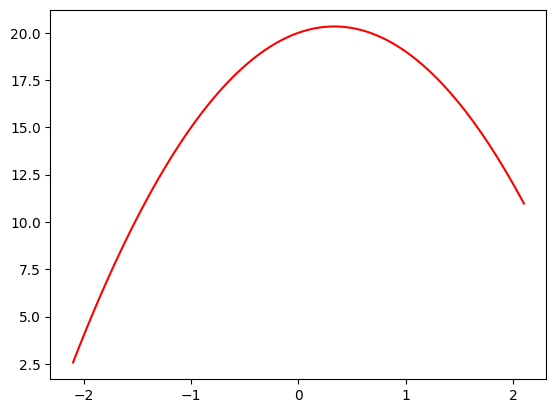

In [77]:
plot_function(f)

For instnace, perhaps we've measured the height above the ground of an object before and after some event. The measurements will have some random error. We can use numpy's random number generator to simulate that. We will use the `seed` when writing about simulations like this so that we see the same thing everytime

In [78]:
from numpy.random import normal, seed, uniform
np.random.seed(42)

In [79]:
def noise(x, scale):
    return normal(scale=scale, size=x.shape)

def add_noise(x, mul, add):
    return x * (1 + noise(x, mul) + noise(x, add))

let's use it to simulate some measurements evenly distributed over time

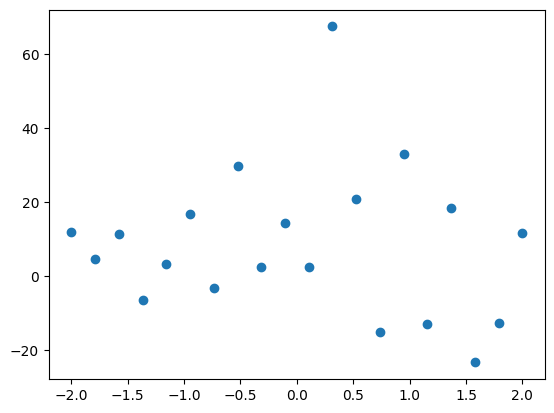

In [80]:
x = np.linspace(-2, 2, num=20)[:None]
y = add_noise(f(x), 0.2, 1.3)
plt.scatter(x,y)

In [81]:
print(x)

[-2.         -1.78947368 -1.57894737 -1.36842105 -1.15789474 -0.94736842
 -0.73684211 -0.52631579 -0.31578947 -0.10526316  0.10526316  0.31578947
  0.52631579  0.73684211  0.94736842  1.15789474  1.36842105  1.57894737
  1.78947368  2.        ]


Now let's see what happens if we underfit or overfit these predictions. To do that, we'll create a function that fits a polynomial of some degree (e.g. a line is degree 1, quadratic is degree 2, cubic is degree 3, etc)

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# def plot_poly(degree):
#     model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
#     model.fit(x.reshape(-1, 1), y)
#     plt.scatter(x, y)
#     plot_function(lambda x: model.predict(x.reshape(-1, 1)),y_lim=(-15,40))


# same funciton as above except this one is broken down for ease of use
def plot_poly(degree):
    # Step 1: create model
    poly = PolynomialFeatures(degree)
    lin = LinearRegression()

    X_poly = poly.fit_transform(x.reshape(-1, 1))
    # print("X_Poly", X_poly)

    # Step 2: train
    lin.fit(X_poly, y)

    # Step 3: plot
    plt.scatter(x, y)

    def f(x_input):
        X_new = poly.transform(x_input.reshape(-1, 1))
        return lin.predict(X_new)

    plot_function(f, y_lim=(-15, 40))

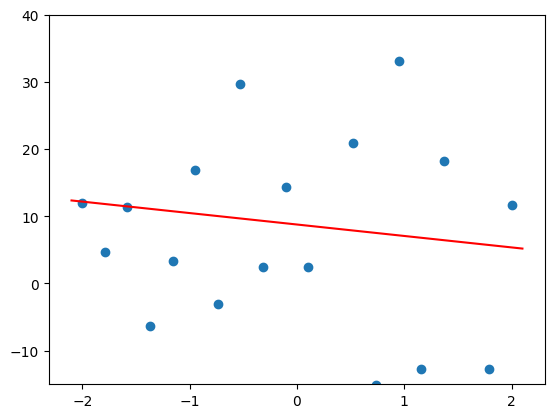

In [83]:
# Udnerdfit Example
plot_poly(1)


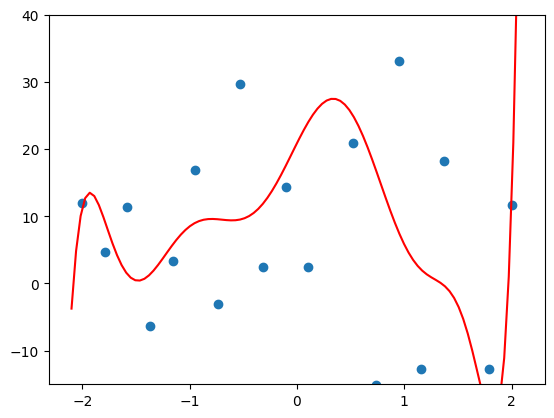

In [84]:
#Overfit example
plot_poly(10)

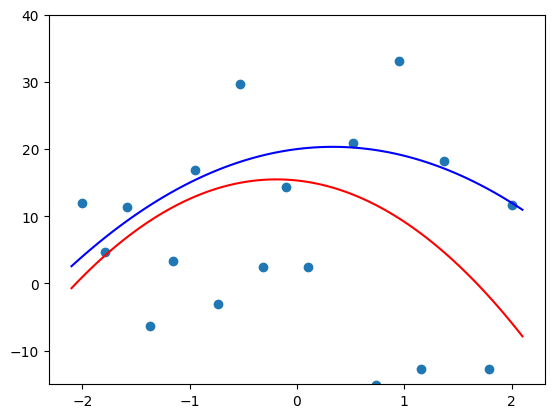

In [85]:
plot_poly(2)
plot_function(f, color='b')

So, how do we recognise whether our models are under-fit, over-fit, or "just right"? We use a validation set. This is a set of data that we "hold out" from training -- we don't let our model see it at all. If you use the fastai library, it automatically creates a validation set for you if you don't have one, and will always report metrics (measurements of the accuracy of a model) using the validation set.

The validation set is only ever used to see how we're doing. It's never used as inputs to training the model.

Transformers uses a DatasetDict for holding your training and validation sets. To create one that contains 25% of our data for the validation set, and 75% for the training set, use `train_test_split`:

In [86]:
dds = tok_ds.train_test_split(0.25, seed=42)
dds

DatasetDict({
    train: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 27354
    })
    test: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9119
    })
})

### Test Set

So that's the validation set explained, and created. What about the "test set" then -- what's that for?

The test set is yet another dataset that's held out from training. But it's held out from reporting metrics too! The accuracy of the model on the test set is only ever checked after we've completed our entire training process, including trying different models, training methods, data processing, etc.

We see, as we try all these different things, to see their impact on the metrics on the validation set, we might just accidentally find a few things that entirely coincidentally improve our validation set metrics, but aren't really better in practice. Given enough time and experiments, we'll find lots of these coincidental improvements. That means we're actually over-fitting to our validation set!

That's why we keep a test set held back. Kaggle's public leaderboard is like a test set that we can check from time to time. But don't check too often, or we'll be even over-fitting to the test set!

Kaggle has a second test set, which is yet another held-out dataset that's only used at the end of the competition to assess our predictions. That's called the "private leaderboard". Here's a great post about what can happen if we overfit to the public leaderboard.

We'll use eval as our name for the test set, to avoid confusion with the test dataset that was created above.

In [87]:
# read the dataset
eval_df = pd.read_csv("./test.csv")
eval_df.head()

,id,anchor,target,context
0,4112d61851461f60,opc drum,inorganic photoconductor drum,G02
1,09e418c93a776564,adjust gas flow,altering gas flow,F23
2,36baf228038e314b,lower trunnion,lower locating,B60
3,1f37ead645e7f0c8,cap component,upper portion,D06
4,71a5b6ad068d531f,neural stimulation,artificial neural network,H04


In [88]:
eval_df['input'] = 'TEXT1: '+ eval_df.context + '; TEXT2: '+ eval_df.target + '; ANC1: ' +eval_df.anchor
eval_ds = Dataset.from_pandas(eval_df).map(tok_func, batched= True)
eval_ds

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 36
})

### Evaluation Metrics

Transformers expects metrics to be returned as a dict, since that way the trainer knows what label to use, so let's create a function to do that

In [89]:
def corr(x,y): return np.corrcoef(x,y)[0][1]

In [ ]:
def corr_d(eval_pred): return {'pearson': corr(*eval_pred)}

In [91]:
import numpy as np

def corr(x, y): return np.corrcoef(x, y)[0][1]
def corr_d(eval_pred): return {'pearson': corr(*eval_pred)}

# dummy test
preds = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
labels = np.array([0.0, 0.25, 0.5, 0.75, 1.0])

print(corr_d((preds, labels)))  # expect ~1.0
print(corr_d((preds, labels[::-1])))  # expect ~-1.0


{'pearson': np.float64(0.9999999999999999)}
{'pearson': np.float64(-0.9999999999999999)}


### Training

To train a modelin Transformers we'll need this

In [92]:
from transformers import TrainingArguments, Trainer

We pick a batch size that fits our GPU, and small number of epochs so we can run experiments quickly:

In [93]:
bs = 128
epochs = 4

The most important hyperparameter is the learning rate. fastai provides a learning rate finder to help you figure this out, but Transformers doesn't, so you'll just have to use trial and error. The idea is to find the largest value you can, but which doesn't result in training failing.

In [94]:
lr = 8e-5

Transformers uses the `TrainingArguments` class to set up arguments. Don't worry too much about the values we're using here -- they should generally work fine in most cases. It's just the 3 parameters above that you may need to change for different models.

In [ ]:
args = TrainingArguments(
    "outputs",
    learning_rate=lr,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    bf16=False,
    fp16=False,
    logging_strategy="epoch",
    eval_strategy="epoch",
    per_device_train_batch_size=bs,
    per_device_eval_batch_size=bs * 2,
    num_train_epochs=epochs,
    weight_decay=0.01,
    report_to="none"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [96]:
import torch

model = AutoModelForSequenceClassification.from_pretrained(
    model_nm, num_labels=1, torch_dtype=torch.float32
)
trainer = Trainer(
    model,
    args,
    train_dataset=dds["train"],
    eval_dataset=dds["test"],
    processing_class=tokz,
    compute_metrics=corr_d,
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias       

delete the output folder before each training to get rid of corrupted checkpoint

In [98]:
import shutil
shutil.rmtree('outputs', ignore_errors=True)

In [99]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Pearson
1,0.045978,0.033776,0.802135
2,0.022111,0.021523,0.823912
3,0.015185,0.021102,0.836872
4,0.012231,0.021795,0.837411


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=856, training_loss=0.023876138101114292, metrics={'train_runtime': 45.3163, 'train_samples_per_second': 2414.498, 'train_steps_per_second': 18.889, 'total_flos': 715555561923540.0, 'train_loss': 0.023876138101114292, 'epoch': 4.0})

Let's do the predictions

In [100]:
preds = trainer.predict(eval_ds).predictions.astype(float)
preds

array([[ 0.56562811],
       [ 0.69201791],
       [ 0.61663324],
       [ 0.33223391],
       [-0.03930722],
       [ 0.47861975],
       [ 0.4581719 ],
       [-0.03065162],
       [ 0.26119167],
       [ 1.11338103],
       [ 0.25561574],
       [ 0.27097505],
       [ 0.73008746],
       [ 0.85151368],
       [ 0.77669656],
       [ 0.41817889],
       [ 0.32261896],
       [-0.02541079],
       [ 0.62527895],
       [ 0.32481325],
       [ 0.46997255],
       [ 0.21947478],
       [ 0.13660504],
       [ 0.22692634],
       [ 0.59300995],
       [-0.02418749],
       [-0.03908709],
       [-0.03617104],
       [-0.03964738],
       [ 0.7028057 ],
       [ 0.34997493],
       [ 0.0229604 ],
       [ 0.70981157],
       [ 0.4959656 ],
       [ 0.43956178],
       [ 0.19411413]])

Look out - some of our predictions are <0, or >1! This once again shows the value of remember to actually look at your data. Let's fix those out-of-bounds predictions:

In [101]:
preds = np.clip(preds, 0, 1)

In [102]:
preds

array([[0.56562811],
       [0.69201791],
       [0.61663324],
       [0.33223391],
       [0.        ],
       [0.47861975],
       [0.4581719 ],
       [0.        ],
       [0.26119167],
       [1.        ],
       [0.25561574],
       [0.27097505],
       [0.73008746],
       [0.85151368],
       [0.77669656],
       [0.41817889],
       [0.32261896],
       [0.        ],
       [0.62527895],
       [0.32481325],
       [0.46997255],
       [0.21947478],
       [0.13660504],
       [0.22692634],
       [0.59300995],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.7028057 ],
       [0.34997493],
       [0.0229604 ],
       [0.70981157],
       [0.4959656 ],
       [0.43956178],
       [0.19411413]])